### aim: maps of hosed world, see hosed-world-ecosystem for how files were extracted

### date: 

In [1]:
%reset

Once deleted, variables cannot be recovered. Proceed (y/[n])?  y


In [2]:
# ================================
# IMPORTS
# ================================
import os
import glob
import pickle
import time
import warnings
from datetime import datetime
from importlib import reload

import numpy as np
import pandas as pd
import xarray as xr
import netCDF4 as nc
import seawater

import matplotlib.pyplot as plt
from matplotlib import font_manager, rcParams
import matplotlib.path as mpath

import cartopy as cp
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from cmocean import cm

# Jupyter magic
%matplotlib inline

# Suppress warnings
warnings.filterwarnings('ignore')

# ================================
# FONT CONFIGURATION
# ================================
# Disable LaTeX (use mathtext with chosen font)
plt.rcParams['text.usetex'] = False

# Base font size
fs = 11

# Path to Gill Sans
gill_sans_path = "/gpfs/home/mep22dku/scratch/FONTS/gill-sans/GillSansMedium.otf"

# Try to load custom font
if os.path.exists(gill_sans_path):
    font_manager.fontManager.addfont(gill_sans_path)
    gill_font_name = font_manager.FontProperties(fname=gill_sans_path).get_name()
    chosen_font = gill_font_name
    print(f"✓ Using custom font: {gill_font_name}")
else:
    chosen_font = "DejaVu Sans"
    print("⚠️ Gill Sans not found, using fallback: DejaVu Sans")

# Apply font settings
rcParams.update({
    'font.size': fs,
    'font.family': chosen_font,
    'axes.titlesize': fs,
    'axes.labelsize': fs,
    'xtick.labelsize': fs,
    'ytick.labelsize': fs,
    'legend.fontsize': fs,
    'mathtext.fontset': 'custom',
    'mathtext.rm': chosen_font,
    'mathtext.it': chosen_font,
    'mathtext.bf': chosen_font,
})

✓ Using custom font: Gill Sans


In [3]:
mask = xr.open_dataset('/gpfs/home/mep22dku/scratch/SOZONE/UTILS/mesh_mask3pt6_nicedims.nc')


In [4]:
#kostelec - polsko
kostelec_6 = ['#C94B3C', '#E47A5C', '#A8B89C', '#6B9B7D', '#7FA4B8', '#4A3830']
kostelec_12 = ['#B23D32', '#C94B3C', '#E47A5C', '#D89B7A', '#E5C9A8', '#C8D4B8', '#A8B89C', '#6B9B7D', '#7FA4B8', '#5B7A8C', '#4A3830', '#2A1F1A']

#prachov - jezero 
prachovjezero_6 = ['#E85A2A', '#F4A63D', '#6B8C3E', '#5B9BAD', '#4A6B8A', '#6B3428']
prachovjezero_12 = ['#D84B28', '#E85A2A', '#F27435', '#F4A63D', '#D4B665', '#89A648', '#6B8C3E', '#4E7054', '#5B9BAD', '#4A6B8A', '#6B3428', '#3D2820']

# Tatry 
tatry_6 = ['#9B7850', '#D4C8A8', '#5B7F68', '#7BA6BC', '#A8BECF', '#3A4F3C']
tatry_12 = ['#7A5F40', '#9B7850', '#C4B090', '#E5D8B8', '#B8D090', '#8FAB80', '#5B7F68', '#5B7B7C', '#7BA6BC', '#A8BECF', '#3A4F3C', '#2B3A2E']
#cesky raj
ceskyraj_6 = ['#B8734E', '#D4A562', '#6B8BA8', '#4B6B8C', '#8B5B7A', '#3A2F28']
ceskyraj_12 = ['#A85C3C', '#B8734E', '#D49558', '#D4A562', '#E5C485', '#9CB68A', '#6B8B72', '#6B8BA8', '#4B6B8C', '#8B5B7A', '#5B3F4A', '#3A2F28']

## prachov - skaly
prachovskaly_6 = ['#B8844E', '#D4A865', '#6B8B5C', '#4B7B8C', '#2B5B8C', '#1B3F5C']
prachovskaly_12 = ['#9B6B3C', '#B8844E', '#C89B5A', '#D4A865', '#E5C68A', '#8BA872', '#6B8B5C', '#4B6B5A', '#5B8B9C', '#4B7B8C', '#2B5B8C', '#1B3F5C']

## jested lanovka
jested_6 = ['#D86B45', '#D4B870', '#8FAB7C', '#5B7B8C', '#6B8BAC', '#3A5B48']
jested_12 = ['#C85B3A', '#D86B45', '#E59B58', '#D4B870', '#E5D090', '#B8C88C', '#8FAB7C', '#6B8B78', '#5B7B8C', '#6B8BAC', '#4B6B5C', '#3A5B48']

## krkonose 
krkonose_6 = ['#E5A542', '#C4D858', '#6B8B5C', '#4B6B8C', '#7A9BAC', '#8B6B47']
krkonose_12 = ['#B87A3C', '#E5A542', '#F5C855', '#D4DB6A', '#C4D858', '#A8C850', '#6B8B5C', '#5B7B6C', '#4B6B8C', '#7A9BAC', '#8B6B47', '#5B4B38']

## dumbier
dumbier_6 = ['#D87845', '#E5C8A0', '#4B7BC2', '#6B9BD8', '#7AB8E5', '#1A2B3A']
dumbier_12 = ['#C86838', '#D87845', '#E59B68', '#E5C8A0', '#F5E8D0', '#A8C8E5', '#7AB8E5', '#6B9BD8', '#4B7BC2', '#3A5B8C', '#2A3B5C', '#1A2B3A']

## assorted snippets

#### notebook footer

In [5]:
def add_notebook_footer(fig, notebook_name, path_y_position=0.02):
    """
    Add notebook path as footer to figure with automatic spacing.
    
    Parameters:
    -----------
    fig : matplotlib figure object
    notebook_name : str
        Name of the notebook file (e.g., 'AMOCts.ipynb')
    path_y_position : float
        Y position for the footer text (default 0.02 = 2% from bottom)
        
    usage 
    bottom_margin = add_notebook_footer(fig, 'AMOCts.ipynb')
    plt.tight_layout(rect=[0, bottom_margin, 1, 0.96])    
    """
    notebook_path = os.path.abspath(os.getcwd())
    full_notebook_path = os.path.join(notebook_path, notebook_name)
    fig.text(0.5, path_y_position, f'Notebook: {full_notebook_path}', ha='center', 
             fontsize=10, style='italic', color='gray')
    
    # Return the bottom margin needed for tight_layout
    return path_y_position + 0.05  # Add buffer above text

In [6]:
sav = False
if sav:
    savenam = 'test2.nc'
    data_vars = {'vomecrty':(['time_counter', 'depthv', 'y', 'x'], vomecrty.values,
    {'units': 'µatm',
    'long_name':'Surface ocean pCO2'}),
    }
    # define coordinates
    coords = {'time_counter': (['time_counter'], time_counter),
            'time_centered': (['time_centered'], time_centered),
    'nav_lat': (['y','x'], nav_lat),
    'nav_lon': (['y','x'], nav_lon),
    'depthv': (['depthv'], depthv)}
    # define global attributes
    attrs = {'made in':'SOZONE/MEDUSA/makeYearlyMEDUSAsubsetfiles.ipynb',
    'desc': 'yearly medusa files, saving only variables of interest'
    }
    ds = xr.Dataset(data_vars=data_vars,
    coords=coords,
    attrs=attrs)
    ds.to_netcdf(savenam)

#### Load data - provincial average
     
     see hosed-world-ecosystem for how made

In [7]:
def make_plist(yrst, yrend, dtype, mod):
    yrs = np.arange(yrst, yrend+1, 1)
    ylist = []
    for i in range(0, len(yrs)):
        ty = f'./data/{mod}_{yrs[i]}_{dtype}_PROV.nc'
        t2 = glob.glob(ty)
        ylist.append(t2[0])
    return ylist

y1 = 2010
y2 = 2019

# Define the models and data types
models = ['TOM12_TJ_LAH3', 'TOM12_TJ_LA50']
dtypes = ['dint_ptrc', 'dint_diad', 'surf100_ptrc', 'diad2d', 'grid_T2d',
         'surf100_LoP','surf100_light',\
         ]

#'surf200_LoP', 'surf100_LoP',

# Create a dictionary to store all datasets_PROV
datasets_PROV = {}

# Load and average all datasets_PROV
for mod in models:
    for dtype in dtypes:
        key = f'{mod}_{dtype}'
        try:
            #print(make_plist(y1, y2, dtype, mod))
            ds = xr.open_mfdataset(make_plist(y1, y2, dtype, mod))
            datasets_PROV[key] = ds.mean(dim='time_counter')
        except:
            print(f'no for {key}')

LAH3_dint_ptrc = datasets_PROV['TOM12_TJ_LAH3_dint_ptrc']
LAH3_dint_diad = datasets_PROV['TOM12_TJ_LAH3_dint_diad']
LAH3_surf100_ptrc = datasets_PROV['TOM12_TJ_LAH3_surf100_ptrc']
# LAH3_surf200_ptrc = datasets_PROV['TOM12_TJ_LAH3_surf200_ptrc']
# LAH3_surf200_LoP = datasets_PROV['TOM12_TJ_LAH3_surf200_LoP']
LAH3_surf100_LoP = datasets_PROV['TOM12_TJ_LAH3_surf100_LoP']
LAH3_diad2d = datasets_PROV['TOM12_TJ_LAH3_diad2d']
LAH3_grid_T2d = datasets_PROV['TOM12_TJ_LAH3_grid_T2d']
#LAH3_surf200_light = datasets_PROV['TOM12_TJ_LAH3_surf200_light']
LAH3_surf100_light = datasets_PROV['TOM12_TJ_LAH3_surf100_light']


LA50_dint_ptrc = datasets_PROV['TOM12_TJ_LA50_dint_ptrc']
LA50_dint_diad = datasets_PROV['TOM12_TJ_LA50_dint_diad']
LA50_surf100_ptrc = datasets_PROV['TOM12_TJ_LA50_surf100_ptrc']
# LA50_surf200_ptrc = datasets_PROV['TOM12_TJ_LA50_surf200_ptrc']
# LA50_surf200_LoP = datasets_PROV['TOM12_TJ_LA50_surf200_LoP']
LA50_surf100_LoP = datasets_PROV['TOM12_TJ_LA50_surf100_LoP']
LA50_diad2d = datasets_PROV['TOM12_TJ_LA50_diad2d']
LA50_grid_T2d = datasets_PROV['TOM12_TJ_LA50_grid_T2d']
#LA50_surf200_light = datasets_PROV['TOM12_TJ_LA50_surf200_light']
LA50_surf100_light = datasets_PROV['TOM12_TJ_LA50_surf100_light']


## not provincially averaged


In [8]:
def make_plist(yrst, yrend, dtype, mod):
    yrs = np.arange(yrst, yrend+1, 1)
    ylist = []
    for i in range(0, len(yrs)):
        ty = f'./data/{mod}_{yrs[i]}_{dtype}.nc'
        t2 = glob.glob(ty)
        ylist.append(t2[0])
    return ylist

y1 = 2010
y2 = 2019

# Define the models and data types
models = ['TOM12_TJ_LAH3', 'TOM12_TJ_LA50']
dtypes = ['dint_ptrc', 'dint_diad', 'surf100_ptrc', 'surf200_ptrc', 'diad2d', 'grid_T2d',
         'surf100_LoP','surf200_LoP','surf100_light','surf200_light',\
         ]

#'surf200_LoP', 'surf100_LoP',

# Create a dictionary to store all datasets
datasets = {}

# Load and average all datasets
for mod in models:
    for dtype in dtypes:
        key = f'{mod}_{dtype}'
        try:
            ds = xr.open_mfdataset(make_plist(y1, y2, dtype, mod))
            datasets[key] = ds.mean(dim='time_counter')
        except:
            print(f'no for {key}')

LAH3_dint_ptrc = datasets['TOM12_TJ_LAH3_dint_ptrc']
LAH3_dint_diad = datasets['TOM12_TJ_LAH3_dint_diad']
LAH3_surf100_ptrc = datasets['TOM12_TJ_LAH3_surf100_ptrc']
# LAH3_surf200_ptrc = datasets['TOM12_TJ_LAH3_surf200_ptrc']
# LAH3_surf200_LoP = datasets['TOM12_TJ_LAH3_surf200_LoP']
LAH3_surf100_LoP = datasets['TOM12_TJ_LAH3_surf100_LoP']
#LAH3_diad2d = datasets['TOM12_TJ_LAH3_diad2d']
#LAH3_grid_T2d = datasets['TOM12_TJ_LAH3_grid_T2d']
# LAH3_surf200_light = datasets['TOM12_TJ_LAH3_surf200_light']
LAH3_surf100_light = datasets['TOM12_TJ_LAH3_surf100_light']


LA50_dint_ptrc = datasets['TOM12_TJ_LA50_dint_ptrc']
LA50_dint_diad = datasets['TOM12_TJ_LA50_dint_diad']
LA50_surf100_ptrc = datasets['TOM12_TJ_LA50_surf100_ptrc']
# LA50_surf200_ptrc = datasets['TOM12_TJ_LA50_surf200_ptrc']
# LA50_surf200_LoP = datasets['TOM12_TJ_LA50_surf200_LoP']
LA50_surf100_LoP = datasets['TOM12_TJ_LA50_surf100_LoP']
#LA50_diad2d = datasets['TOM12_TJ_LA50_diad2d']
#LA50_grid_T2d = datasets['TOM12_TJ_LA50_grid_T2d']
# LA50_surf200_light = datasets['TOM12_TJ_LA50_surf200_light']
LA50_surf100_light = datasets['TOM12_TJ_LA50_surf100_light']


no for TOM12_TJ_LAH3_surf200_ptrc
no for TOM12_TJ_LAH3_diad2d
no for TOM12_TJ_LAH3_grid_T2d
no for TOM12_TJ_LAH3_surf200_LoP
no for TOM12_TJ_LAH3_surf200_light
no for TOM12_TJ_LA50_surf200_ptrc
no for TOM12_TJ_LA50_diad2d
no for TOM12_TJ_LA50_grid_T2d
no for TOM12_TJ_LA50_surf200_LoP
no for TOM12_TJ_LA50_surf200_light


## Phyto assemblage maps:

base run:
    LA50 and LAH3 ecosystems
    
    depth-integrated made by SOZONE/UTILS/utils.py integrate_depth
    see hosed_world_ecosystem for how they were extracted 

In [9]:
LAH3_phy = xr.open_dataset('./data/TJ_LAH3_depthint_phyto_2010-2019.nc')
LA50_phy = xr.open_dataset('./data/TJ_LA50_depthint_phyto_2010-2019.nc')




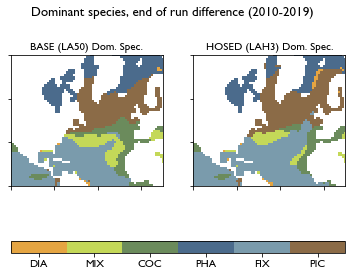

In [10]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
import numpy as np
import xarray as xr

# 1. Define the custom 6-color palette
krkonose_6 = ['#E5A542', '#C4D858', '#6B8B5C', '#4B6B8C', '#7A9BAC', '#8B6B47']
labels = ['DIA','MIX','COC','PHA','FIX','PIC']

# Create the colormap and the normalization
cmap = mcolors.ListedColormap(krkonose_6)
bounds = np.arange(0.5, 7.5, 1)
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# 2. Set limits
xlims = (80, 150)
ylims = (80, 140)

# 3. Create figure with GridSpec for more control
fact = 0.5
fig = plt.figure(figsize=(12*fact, 8*fact))
gs = gridspec.GridSpec(2, 2, figure=fig, height_ratios=[15, 1], hspace=0.4)

# Create the two plot axes
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
axes = [ax1, ax2]

# Create colorbar axis at the bottom
cbar_ax = fig.add_subplot(gs[1, :])

# List of your DataArrays
datasets = [LA50_phy.dominant_species_yearly, LAH3_phy.dominant_species_yearly]
titles = ['BASE (LA50) Dom. Spec.', 'HOSED (LAH3) Dom. Spec.']

for ax, data, title in zip(axes, datasets, titles):
    # Plot using xarray's pcolormesh wrapper
    im = data.plot.pcolormesh(
        ax=ax, 
        x='x', 
        y='y', 
        cmap=cmap, 
        norm=norm, 
        add_colorbar=False
    )
    
    # Set limits
    ax.set_xlim(xlims)
    ax.set_ylim(ylims)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_title(title)
    ax.set_aspect('equal')

# 4. Add colorbar in the dedicated axis
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
cbar.set_ticks(np.arange(1, 7))
cbar.set_ticklabels(labels)
plt.suptitle('Dominant species, end of run difference (2010-2019)')
fig.savefig('./plts/phyto-dom.jpg')
plt.show()


LAH3_surf100_LoP

## lop

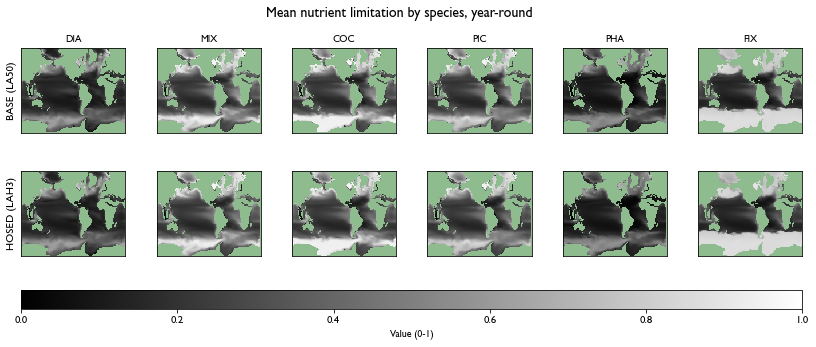

In [38]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
import numpy as np
import xarray as xr

# Define variables to plot
variables = ['LV_DIA', 'LV_MIX', 'LV_COC', 'LV_PIC', 'LV_PHA', 'LV_FIX']
labels = ['DIA', 'MIX', 'COC', 'PIC', 'PHA', 'FIX']

# Create colormap: black (0) to white (1)
cmap = mcolors.LinearSegmentedColormap.from_list('black_white', ['black', 'white'])
norm = mcolors.Normalize(vmin=0, vmax=1)

# xlims = (80, 150)
# ylims = (80, 140)

xlims = (None, None)
ylims = (None, None)

# Your datasets
datasets = [LA50_surf100_LoP, LAH3_surf100_LoP]
dataset_names = ['BASE (LA50)', 'HOSED (LAH3)']

# Load mask
#mask = xr.open_dataset('path_to_your_mask_file.nc')  # Update path as needed

# Create figure with GridSpec
fact = 0.7
fig = plt.figure(figsize=(20*fact, 7*fact))
gs = gridspec.GridSpec(3, 6, figure=fig, hspace=0.4, wspace=0.3, height_ratios=[1, 1, 0.2])

# Add suptitle
fig.suptitle('Mean nutrient limitation by species, year-round', fontsize=14, fontweight='bold', y=0.98)

# Create plot axes (2 rows, 6 columns)
axes = []
for i in range(2):
    row = []
    for j in range(6):
        ax = fig.add_subplot(gs[i, j])
        row.append(ax)
    axes.append(row)

# Create colorbar axis
cbar_ax = fig.add_subplot(gs[2, :])

# Plot each dataset
im = None
for dataset_idx, (dataset, dataset_name) in enumerate(zip(datasets, dataset_names)):
    for var_idx, (var, label) in enumerate(zip(variables, labels)):
        ax = axes[dataset_idx][var_idx]
        
        # Apply mask where tmaskutil == 0
        data_masked = dataset[var].where(mask.tmaskutil != 0)
        
        # Plot the variable
        im = data_masked.plot.pcolormesh(
            ax=ax,
            x='x',
            y='y',
            cmap=cmap,
            norm=norm,
            add_colorbar=False,
            shading='auto'
        )
        
        # Add masked area in light green
        masked_area = mask.tmaskutil.where(mask.tmaskutil == 0)
        masked_area.plot.pcolormesh(
            ax=ax,
            x='x',
            y='y',
            cmap=mcolors.ListedColormap(['darkseagreen']),
            add_colorbar=False,
            shading='auto'
        )
        
        ax.set_xticklabels([])
        ax.set_yticklabels([])
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.set_xlim(xlims)
        ax.set_ylim(ylims)
        
        # Title only on first row
        if dataset_idx == 0:
            ax.set_title(label, fontsize=10, fontweight='bold')
        
        # Row label on left
        if var_idx == 0:
            ax.set_ylabel(dataset_name, fontsize=11, fontweight='bold')
        
        ax.set_aspect('equal')

# Add single colorbar
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Value (0-1)', fontsize=10)
plt.savefig('./plts/nutrient-lim.jpg')
plt.show()


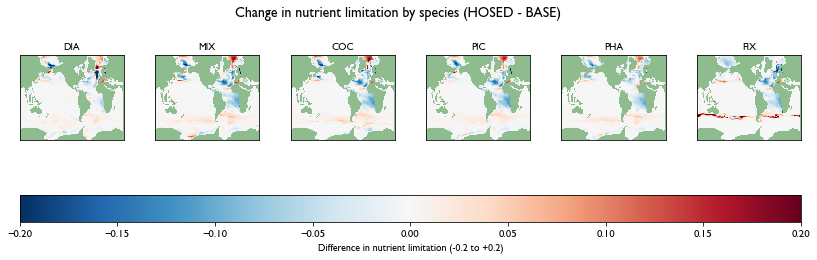

In [39]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
import numpy as np
import xarray as xr

# Define variables to plot
variables = ['LV_DIA', 'LV_MIX', 'LV_COC', 'LV_PIC', 'LV_PHA', 'LV_FIX']
labels = ['DIA', 'MIX', 'COC', 'PIC', 'PHA', 'FIX']

# Create diverging colormap (blue for negative, red for positive)
cmap = plt.cm.RdBu_r
norm = mcolors.Normalize(vmin=-0.2, vmax=0.2)

# xlims = (80, 150)
# ylims = (80, 140)

# Your datasets
dataset1 = LA50_surf100_LoP
dataset2 = LAH3_surf100_LoP
dataset_names = ['Difference (HOSED - BASE)']

# Load mask
#mask = xr.open_dataset('path_to_your_mask_file.nc')  # Update path as needed

# Create figure with GridSpec
fact = 0.7
fig = plt.figure(figsize=(20*fact, 5*fact))
gs = gridspec.GridSpec(2, 6, figure=fig, hspace=0.4, wspace=0.3, height_ratios=[1, 0.2])

# Add suptitle
fig.suptitle('Change in nutrient limitation by species (HOSED - BASE)', fontsize=14, fontweight='bold', y=0.98)

# Create plot axes (1 row, 6 columns)
axes = []
for j in range(6):
    ax = fig.add_subplot(gs[0, j])
    axes.append(ax)

# Create colorbar axis
cbar_ax = fig.add_subplot(gs[1, :])

# Plot difference
im = None
for var_idx, (var, label) in enumerate(zip(variables, labels)):
    ax = axes[var_idx]
    
    # Calculate difference
    data_diff = dataset2[var] - dataset1[var]
    
    # Apply mask where tmaskutil == 0
    data_masked = data_diff.where(mask.tmaskutil != 0)
    
    # Plot the variable
    im = data_masked.plot.pcolormesh(
        ax=ax,
        x='x',
        y='y',
        cmap=cmap,
        norm=norm,
        add_colorbar=False,
        shading='auto'
    )
    
    # Add masked area in light green
    masked_area = mask.tmaskutil.where(mask.tmaskutil == 0)
    masked_area.plot.pcolormesh(
        ax=ax,
        x='x',
        y='y',
        cmap=mcolors.ListedColormap(['darkseagreen']),
        add_colorbar=False,
        shading='auto'
    )
    
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xlim(xlims)
    ax.set_ylim(ylims)
    
    # Title
    ax.set_title(label, fontsize=10, fontweight='bold')
    
    ax.set_aspect('equal')

# Add single colorbar
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Difference in nutrient limitation (-0.2 to +0.2)', fontsize=10)
plt.savefig('./plts/nutrient-lim-diff.jpg')
plt.show()

## light limitation

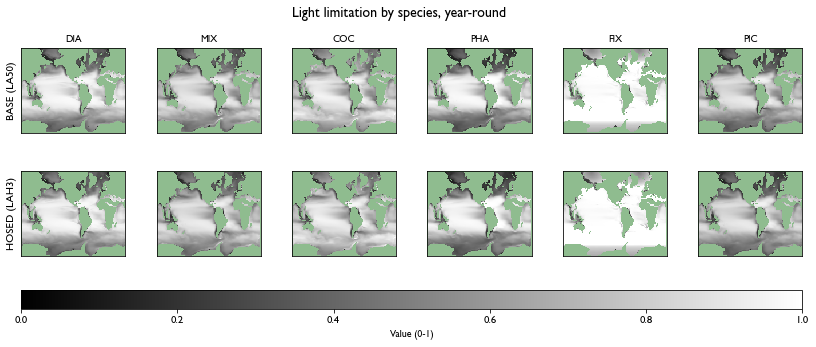

In [40]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
import numpy as np
import xarray as xr

# Define variables to plot
variables = ['lim8light_dia', 'lim8light_mix', 'lim8light_coc', 'lim8light_pha', 'lim8light_fix', 'lim8light_pic']
labels = ['DIA', 'MIX', 'COC', 'PHA', 'FIX', 'PIC']

# Create colormap: black (0) to white (1)
cmap = mcolors.LinearSegmentedColormap.from_list('black_white', ['black', 'white'])
norm = mcolors.Normalize(vmin=0, vmax=1)

# xlims = (80, 150)
# ylims = (80, 140)

# Your datasets
datasets = [LA50_surf100_light, LAH3_surf100_light]
dataset_names = ['BASE (LA50)', 'HOSED (LAH3)']

# Load mask
#mask = xr.open_dataset('path_to_your_mask_file.nc')  # Update path as needed

# Create figure with GridSpec
fact = 0.7
fig = plt.figure(figsize=(20*fact, 7*fact))
gs = gridspec.GridSpec(3, 6, figure=fig, hspace=0.4, wspace=0.3, height_ratios=[1, 1, 0.2])

# Add suptitle
fig.suptitle('Light limitation by species, year-round', fontsize=14, fontweight='bold', y=0.98)

# Create plot axes (2 rows, 6 columns)
axes = []
for i in range(2):
    row = []
    for j in range(6):
        ax = fig.add_subplot(gs[i, j])
        row.append(ax)
    axes.append(row)

# Create colorbar axis
cbar_ax = fig.add_subplot(gs[2, :])

# Plot each dataset
im = None
for dataset_idx, (dataset, dataset_name) in enumerate(zip(datasets, dataset_names)):
    for var_idx, (var, label) in enumerate(zip(variables, labels)):
        ax = axes[dataset_idx][var_idx]
        
        # Apply mask where tmaskutil == 0
        data_masked = dataset[var].where(mask.tmaskutil != 0)
        
        # Plot the variable
        im = data_masked.plot.pcolormesh(
            ax=ax,
            x='x',
            y='y',
            cmap=cmap,
            norm=norm,
            add_colorbar=False,
            shading='auto'
        )
        
        # Add masked area in light green
        masked_area = mask.tmaskutil.where(mask.tmaskutil == 0)
        masked_area.plot.pcolormesh(
            ax=ax,
            x='x',
            y='y',
            cmap=mcolors.ListedColormap(['darkseagreen']),
            add_colorbar=False,
            shading='auto'
        )
        
        ax.set_xticklabels([])
        ax.set_yticklabels([])
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.set_xlim(xlims)
        ax.set_ylim(ylims)
        
        # Title only on first row
        if dataset_idx == 0:
            ax.set_title(label, fontsize=10, fontweight='bold')
        
        # Row label on left
        if var_idx == 0:
            ax.set_ylabel(dataset_name, fontsize=11, fontweight='bold')
        
        ax.set_aspect('equal')

# Add single colorbar
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Value (0-1)', fontsize=10)

plt.savefig('./plts/light-lim.jpg')
plt.show()

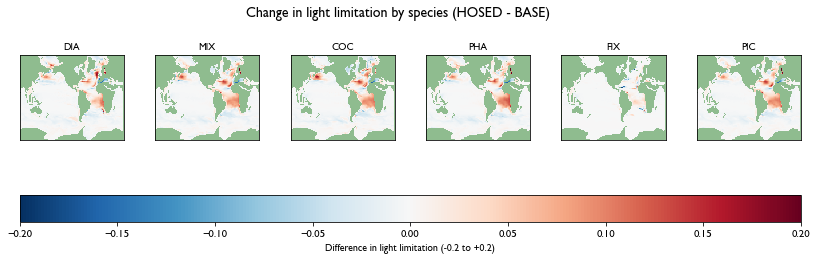

In [41]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
import numpy as np
import xarray as xr

# Define variables to plot
variables = ['lim8light_dia', 'lim8light_mix', 'lim8light_coc', 'lim8light_pha', 'lim8light_fix', 'lim8light_pic']
labels = ['DIA', 'MIX', 'COC', 'PHA', 'FIX', 'PIC']

# Create diverging colormap (blue for negative, red for positive)
cmap = plt.cm.RdBu_r
norm = mcolors.Normalize(vmin=-0.2, vmax=0.2)

# xlims = (80, 150)
# ylims = (80, 140)

# Your datasets
dataset1 = LA50_surf100_light
dataset2 = LAH3_surf100_light

# Load mask
#mask = xr.open_dataset('path_to_your_mask_file.nc')  # Update path as needed

# Create figure with GridSpec
fact = 0.7
fig = plt.figure(figsize=(20*fact, 5*fact))
gs = gridspec.GridSpec(2, 6, figure=fig, hspace=0.4, wspace=0.3, height_ratios=[1, 0.2])

# Add suptitle
fig.suptitle('Change in light limitation by species (HOSED - BASE)', fontsize=14, fontweight='bold', y=0.98)

# Create plot axes (1 row, 6 columns)
axes = []
for j in range(6):
    ax = fig.add_subplot(gs[0, j])
    axes.append(ax)

# Create colorbar axis
cbar_ax = fig.add_subplot(gs[1, :])

# Plot difference
im = None
for var_idx, (var, label) in enumerate(zip(variables, labels)):
    ax = axes[var_idx]
    
    # Calculate difference
    data_diff = dataset2[var] - dataset1[var]
    
    # Apply mask where tmaskutil == 0
    data_masked = data_diff.where(mask.tmaskutil != 0)
    
    # Plot the variable
    im = data_masked.plot.pcolormesh(
        ax=ax,
        x='x',
        y='y',
        cmap=cmap,
        norm=norm,
        add_colorbar=False,
        shading='auto'
    )
    
    # Add masked area in light green
    masked_area = mask.tmaskutil.where(mask.tmaskutil == 0)
    masked_area.plot.pcolormesh(
        ax=ax,
        x='x',
        y='y',
        cmap=mcolors.ListedColormap(['darkseagreen']),
        add_colorbar=False,
        shading='auto'
    )
    
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xlim(xlims)
    ax.set_ylim(ylims)
    
    # Title
    ax.set_title(label, fontsize=10, fontweight='bold')
    
    ax.set_aspect('equal')

# Add single colorbar
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Difference in light limitation (-0.2 to +0.2)', fontsize=10)

plt.savefig('./plts/light-lim-diff.jpg')
plt.show()

## depth integrated ppt

In [34]:
LA50_dint_diad

<xarray.Dataset>
Dimensions:  (x: 182, y: 149)
Coordinates:
    nav_lon  (y, x) float32 dask.array<chunksize=(149, 182), meta=np.ndarray>
    nav_lat  (y, x) float32 dask.array<chunksize=(149, 182), meta=np.ndarray>
Dimensions without coordinates: x, y
Data variables:
    PPT_DIA  (y, x) float64 dask.array<chunksize=(149, 182), meta=np.ndarray>
    PPT_MIX  (y, x) float64 dask.array<chunksize=(149, 182), meta=np.ndarray>
    PPT_COC  (y, x) float64 dask.array<chunksize=(149, 182), meta=np.ndarray>
    PPT_PIC  (y, x) float64 dask.array<chunksize=(149, 182), meta=np.ndarray>
    PPT_PHA  (y, x) float64 dask.array<chunksize=(149, 182), meta=np.ndarray>
    PPT_FIX  (y, x) float64 dask.array<chunksize=(149, 182), meta=np.ndarray>
    TChl     (y, x) float64 dask.array<chunksize=(149, 182), meta=np.ndarray>
    PPT      (y, x) float64 dask.array<chunksize=(149, 182), meta=np.ndarray>

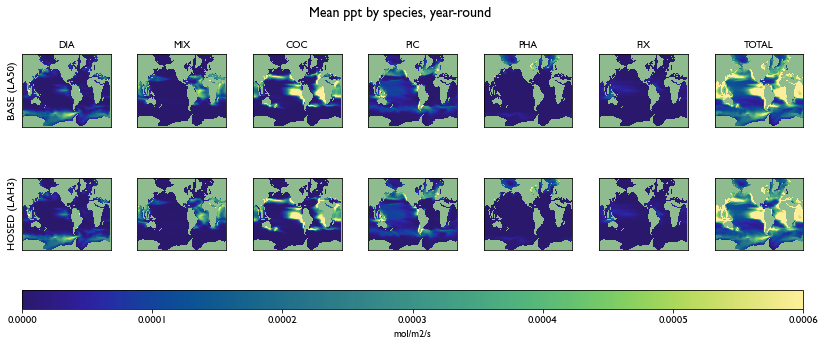

In [37]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
import numpy as np
import xarray as xr

# Define variables to plot
variables = ['PPT_DIA', 'PPT_MIX', 'PPT_COC', 'PPT_PIC', 'PPT_PHA', 'PPT_FIX','PPT']
labels = ['DIA', 'MIX', 'COC', 'PIC', 'PHA', 'FIX','TOTAL']

# Define vmin and vmax for colorbar
vmin = 0
vmax = 6e-4

xlims = (80, 150)
ylims = (80, 140)
xlims = (None, None)
ylims = (None, None)


# Your datasets
datasets = [LA50_dint_diad, LAH3_dint_diad]
dataset_names = ['BASE (LA50)', 'HOSED (LAH3)']

LAH3_dint_diad['PPT'] = LAH3_dint_diad['PPT_DIA'] + LAH3_dint_diad['PPT_MIX'] + LAH3_dint_diad['PPT_COC'] +\
LAH3_dint_diad['PPT_PIC'] + LAH3_dint_diad['PPT_PHA'] + LAH3_dint_diad['PPT_FIX'] 

LA50_dint_diad['PPT'] = LA50_dint_diad['PPT_DIA'] + LA50_dint_diad['PPT_MIX'] + LA50_dint_diad['PPT_COC'] +\
LA50_dint_diad['PPT_PIC'] + LA50_dint_diad['PPT_PHA'] + LA50_dint_diad['PPT_FIX'] 

# Load mask
#mask = xr.open_dataset('path_to_your_mask_file.nc')  # Update path as needed

# Create figure with GridSpec
fact = 0.7
fig = plt.figure(figsize=(20*fact, 7*fact))
gs = gridspec.GridSpec(3, 7, figure=fig, hspace=0.4, wspace=0.3, height_ratios=[1, 1, 0.2])

# Add suptitle
fig.suptitle('Mean ppt by species, year-round', fontsize=14, fontweight='bold', y=0.98)

# Create plot axes (2 rows, 6 columns)
axes = []
for i in range(2):
    row = []
    for j in range(7):
        ax = fig.add_subplot(gs[i, j])
        row.append(ax)
    axes.append(row)

# Create colorbar axis
cbar_ax = fig.add_subplot(gs[2, :])

# Plot each dataset
im = None
for dataset_idx, (dataset, dataset_name) in enumerate(zip(datasets, dataset_names)):
    for var_idx, (var, label) in enumerate(zip(variables, labels)):
        ax = axes[dataset_idx][var_idx]
        
        # Apply mask where tmaskutil == 0
        data_masked = dataset[var].where(mask.tmaskutil != 0)
        
        # Plot the variable with vmin and vmax
        im = data_masked.plot.pcolormesh(
            ax=ax,
            x='x',
            y='y',
            cmap=cm.haline,
            add_colorbar=False,
            shading='auto',
            vmin=vmin,
            vmax=vmax
        )
        
        # Add masked area in light green
        masked_area = mask.tmaskutil.where(mask.tmaskutil == 0)
        masked_area.plot.pcolormesh(
            ax=ax,
            x='x',
            y='y',
            cmap=mcolors.ListedColormap(['darkseagreen']),
            add_colorbar=False,
            shading='auto'
        )
        
        ax.set_xticklabels([])
        ax.set_yticklabels([])
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.set_xlim(xlims)
        ax.set_ylim(ylims)
        
        # Title only on first row
        if dataset_idx == 0:
            ax.set_title(label, fontsize=10, fontweight='bold')
        
        # Row label on left
        if var_idx == 0:
            ax.set_ylabel(dataset_name, fontsize=11, fontweight='bold')
        
        ax.set_aspect('equal')

# Add single colorbar
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
cbar.set_label('mol/m2/s', fontsize=10)

plt.savefig('./plts/ppt.jpg')
plt.show()

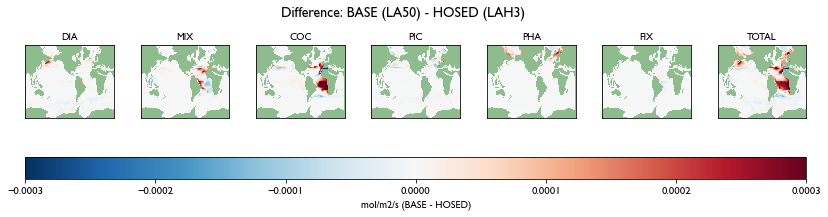

In [36]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
import numpy as np
import xarray as xr

# Define variables to plot
variables = ['PPT_DIA', 'PPT_MIX', 'PPT_COC', 'PPT_PIC', 'PPT_PHA', 'PPT_FIX','PPT']
labels = ['DIA', 'MIX', 'COC', 'PIC', 'PHA', 'FIX','TOTAL']

# Define vmin and vmax for colorbar (symmetric around zero)
vmin = -3e-4
vmax = 3e-4
xlims = (None, None)
ylims = (None, None)

# Your datasets
LAH3_dint_diad['PPT'] = LAH3_dint_diad['PPT_DIA'] + LAH3_dint_diad['PPT_MIX'] + LAH3_dint_diad['PPT_COC'] +\
LAH3_dint_diad['PPT_PIC'] + LAH3_dint_diad['PPT_PHA'] + LAH3_dint_diad['PPT_FIX'] 
LA50_dint_diad['PPT'] = LA50_dint_diad['PPT_DIA'] + LA50_dint_diad['PPT_MIX'] + LA50_dint_diad['PPT_COC'] +\
LA50_dint_diad['PPT_PIC'] + LA50_dint_diad['PPT_PHA'] + LA50_dint_diad['PPT_FIX'] 

# Create figure with GridSpec
fact = 0.7
fig = plt.figure(figsize=(20*fact, 4*fact))
gs = gridspec.GridSpec(2, 7, figure=fig, hspace=0.3, wspace=0.3, height_ratios=[1, 0.2])

# Add suptitle
fig.suptitle('Difference: BASE (LA50) - HOSED (LAH3)', fontsize=14, fontweight='bold', y=0.98)

# Create plot axes (1 row for difference, 1 for colorbar)
axes = []
for j in range(7):
    ax = fig.add_subplot(gs[0, j])
    axes.append(ax)

# Create colorbar axis
cbar_ax = fig.add_subplot(gs[1, :])

# Plot differences
im = None
for var_idx, (var, label) in enumerate(zip(variables, labels)):
    ax = axes[var_idx]
    
    # Calculate difference: BASE - HOSED
    diff = LA50_dint_diad[var] - LAH3_dint_diad[var]
    
    # Apply mask where tmaskutil == 0
    diff_masked = diff.where(mask.tmaskutil != 0)
    
    # Plot the difference with symmetric colormap (diverging)
    im = diff_masked.plot.pcolormesh(
        ax=ax,
        x='x',
        y='y',
        cmap='RdBu_r',  # Red-Blue diverging colormap (red=positive, blue=negative)
        add_colorbar=False,
        shading='auto',
        vmin=vmin,
        vmax=vmax
    )
    
    # Add masked area in light green
    masked_area = mask.tmaskutil.where(mask.tmaskutil == 0)
    masked_area.plot.pcolormesh(
        ax=ax,
        x='x',
        y='y',
        cmap=mcolors.ListedColormap(['darkseagreen']),
        add_colorbar=False,
        shading='auto'
    )
    
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xlim(xlims)
    ax.set_ylim(ylims)
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_aspect('equal')

# Add single colorbar
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
cbar.set_label('mol/m2/s (BASE - HOSED)', fontsize=10)

plt.savefig('./plts/ppt_diff.jpg', dpi=300, bbox_inches='tight')
plt.show()

## bordel

In [15]:
# sys.path.append('/gpfs/home/mep22dku/scratch/SOZONE/UTILS/')
# import utils as ut

def make_yearlist(yrst, yrend, dtype, modnam, bD = './data/'):

    '''
    open many files together as the same dataset
    ylist = make_yearlist(2001,2011,'diad_T','TOM12_TJ_1AS1')
    ds = xr.open_mfdataset(ylist)
    
    '''
    bD = f'{bD}/'
    yrs = np.arange(yrst,yrend+1,1)
    ylist = []
    for i in range(0,len(yrs)):
        ty = f'{bD}/{modnam}_{yrs[i]}_{dtype}.nc'
        ylist.append(ty)
    return ylist

#TOM12_TJ_LAH3_2020_dint_diad.nc

LAH3_ptrc = xr.open_mfdataset(make_yearlist(2010, 2019, 'dint_ptrc', 'TOM12_TJ_LAH3', bD = './data/'))

In [1]:
import xarray as xr

In [5]:
w = xr.open_dataset('/gpfs/data/greenocean/software/runs//TOM12_TJ_LA50/ORCA2_1m_clim_2010_2011_grid_T.nc')


In [6]:
w

<xarray.Dataset>
Dimensions:        (axis_nbounds: 2, deptht: 31, month: 12, x: 182, y: 149)
Coordinates:
    nav_lat        (y, x) float32 ...
    nav_lon        (y, x) float32 ...
  * deptht         (deptht) float32 5.0 15.0 25.0 ... 4.25e+03 4.75e+03 5.25e+03
  * month          (month) int64 1 2 3 4 5 6 7 8 9 10 11 12
Dimensions without coordinates: axis_nbounds, x, y
Data variables: (12/18)
    deptht_bounds  (month, deptht, axis_nbounds) float32 ...
    e3t            (month, deptht, y, x) float32 ...
    votemper       (month, deptht, y, x) float32 ...
    vosaline       (month, deptht, y, x) float32 ...
    tos            (month, y, x) float32 ...
    sos            (month, y, x) float32 ...
    ...             ...
    tohfls         (month, y, x) float32 ...
    sosflxdo       (month, y, x) float32 ...
    taum           (month, y, x) float32 ...
    sowindsp       (month, y, x) float32 ...
    soprecip       (month, y, x) float32 ...
    sbt            (month, y, x) float32 ...